**Installing necessary libarary & Data importing, viewing**

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from arch import arch_model

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving crypto_volatility_dec2025_FINAL_2025-12-09.csv to crypto_volatility_dec2025_FINAL_2025-12-09.csv


In [ ]:
crypto= pd.read_csv("crypto_volatility_dec2025_FINAL_2025-12-09.csv")

In [ ]:
crypto.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65201 entries, 0 to 65200
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  65201 non-null  object 
 1   open       65201 non-null  float64
 2   high       65201 non-null  float64
 3   low        65201 non-null  float64
 4   close      65201 non-null  float64
 5   volume     65201 non-null  int64  
 6   asset      65201 non-null  object 
 7   symbol     65201 non-null  object 
dtypes: float64(4), int64(1), object(3)
memory usage: 4.0+ MB


In [ ]:
crypto.head()

,timestamp,open,high,low,close,volume,asset,symbol
0,2025-12-03 00:00:00+00:00,91345.31250,91345.31250,91345.31250,91345.31250,0,Bitcoin,BTC-USD
1,2025-12-03 00:01:00+00:00,91382.49219,91382.49219,91382.49219,91382.49219,173711360,Bitcoin,BTC-USD
2,2025-12-03 00:02:00+00:00,91402.96875,91402.96875,91402.96875,91402.96875,0,Bitcoin,BTC-USD
3,2025-12-03 00:03:00+00:00,91364.12500,91364.12500,91364.12500,91364.12500,173981696,Bitcoin,BTC-USD
4,2025-12-03 00:05:00+00:00,91294.81250,91294.81250,91294.81250,91294.81250,0,Bitcoin,BTC-USD


In [ ]:
crypto.tail()

,timestamp,open,high,low,close,volume,asset,symbol
65196,2025-12-09 15:49:00+00:00,1.822647,1.822647,1.822647,1.822647,1349744,Near Protocol,NEAR-USD
65197,2025-12-09 15:50:00+00:00,1.822844,1.822844,1.822844,1.822844,168608,Near Protocol,NEAR-USD
65198,2025-12-09 15:53:00+00:00,1.832638,1.832638,1.832638,1.832638,1632992,Near Protocol,NEAR-USD
65199,2025-12-09 15:54:00+00:00,1.831507,1.831507,1.831507,1.831507,155504,Near Protocol,NEAR-USD
65200,2025-12-09 15:55:00+00:00,1.833035,1.833035,1.833035,1.833035,1099072,Near Protocol,NEAR-USD


In [ ]:
# filters only value of assets in ethereum rows
eth_data = crypto[crypto['asset'] == 'Ethereum']


In [ ]:
eth_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8784 entries, 8687 to 17470
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  8784 non-null   object 
 1   open       8784 non-null   float64
 2   high       8784 non-null   float64
 3   low        8784 non-null   float64
 4   close      8784 non-null   float64
 5   volume     8784 non-null   int64  
 6   asset      8784 non-null   object 
 7   symbol     8784 non-null   object 
dtypes: float64(4), int64(1), object(3)
memory usage: 617.6+ KB


In [ ]:
# select only open of Ethereum rows
returns = eth_data['open'].dropna()

In [ ]:
returns.head()

,open
8687,2997.803711
8688,3000.079834
8689,2999.305176
8690,3000.022949
8691,2997.795654


In [ ]:
#feature re-engineering (could have taken log but my purpose is just working with representative data) [scaling down the data uniformly]
returns_scaled = returns * 0.01

**GARCH MODEL**

In [ ]:
# Fitting the GARCH(1,1) model
garchbit = arch_model(returns_scaled, vol='Garch', p=1, q=1)

In [ ]:
garch_fit = garchbit.fit()

# Print summary
print(garch_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 465084348.98047304
Iteration:      2,   Func. Count:     20,   Neg. LLF: 238551937570.4886
Iteration:      3,   Func. Count:     27,   Neg. LLF: 581190.2906134762
Iteration:      4,   Func. Count:     39,   Neg. LLF: 75341.17385650137
Iteration:      5,   Func. Count:     48,   Neg. LLF: 4429.095837761745
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4429.095806660186
            Iterations: 9
            Function evaluations: 48
            Gradient evaluations: 5
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   open   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4429.10
Distribution:                  Normal   AIC:                           8866.19
Method:            Maximum Likelihood

Interpreting Garch Results:
Alpa and beta shouldbe statistically significant at 95% confidence interval.
R^2 is zero as it is not OLS regression , it is Log likelihood function.

1) Omega or Alpha0 is significant, indicating baseline volatility.
2) Alpha[1] measures impact of recent shocks.
3) Beta [1] measures persistent volatility.


A common criteria to measure weather GARCH model suits the data, is to check if, Alpha + Beta = 1.

1) If Alpha + Beta near to 1 (~1) this indicates highly persistent voatility in the data.
2) If Alpha + Beta less than 1 (<1), indicates a stable GARCH (GArch is capturing all patterns in the data)
3) If Alpha + Beta greater than 1 (>1), indicates unstable GARCH (GARCH is not capturing volatility)


In the current data, ALpha + Beta ~1.

It indicates that, the Ethereum data, has highly persistent volatility. The GARCH model, is able to capture some elements of the volatilty, but not all!


We can do a forecasting, but it isn't perfect

In [ ]:
# Forecast next 5 periods
forecast = garch_fit.forecast(horizon=5)

# Extract variance forecast
print(forecast.variance[-1:])

           h.1       h.2       h.3       h.4       h.5
17470  1.40268  1.331178  1.263658  1.199896  1.139684


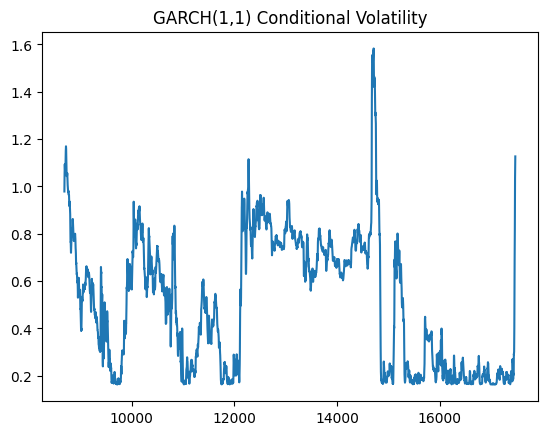

In [ ]:
#plotting the volatility of the data
import matplotlib.pyplot as plt

plt.figure()
plt.plot(garch_fit.conditional_volatility)
plt.title("GARCH(1,1) Conditional Volatility")
plt.show()

we see alot of volatility, hence the model is not perfect.

### **TGARCH**

In [ ]:
from arch import arch_model

# TGARCH (GJR-GARCH) model
tgarch_model = arch_model(returns_scaled, vol='Garch', p=1, o=1, q=1)

tgarch_fit = tgarch_model.fit()

print(tgarch_fit.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 2.2297400049630042e+18
Iteration:      2,   Func. Count:     22,   Neg. LLF: 3082674676911985.5
Iteration:      3,   Func. Count:     33,   Neg. LLF: 37509.32799200701
Iteration:      4,   Func. Count:     43,   Neg. LLF: 4985505595227590.0
Iteration:      5,   Func. Count:     54,   Neg. LLF: 43297.22359084067
Iteration:      6,   Func. Count:     62,   Neg. LLF: 188380149.51355907
Iteration:      7,   Func. Count:     69,   Neg. LLF: 845950.9827111373
Iteration:      8,   Func. Count:     81,   Neg. LLF: 44175184580.45598
Iteration:      9,   Func. Count:     88,   Neg. LLF: 7832.708708757045
Iteration:     10,   Func. Count:     96,   Neg. LLF: 15595.572746758882
Iteration:     11,   Func. Count:    103,   Neg. LLF: 10545.979945283094
Iteration:     12,   Func. Count:    111,   Neg. LLF: 7076.2448485810155
Iteration:     13,   Func. Count:    119,   Neg. LLF: 4598.29110184801
Iteration:     14,   Func. Count:    125,   Neg. LLF: 


TGARCH is better than GARCH.
AIC and BIC are lesser in TGARCH than in GARCH (AIC / BIC,    lesser the bettter)


1) Gamma measures the assymetric volatility. It is  significant at 95%, indicating presence of asymetric volatility in Ethereum data. p value is lesser than 0.05, indicating significance.

2) Alpha+Beta < 1. indicating that the data might is sufficiently captured by TGARCH model.

3) Most of the metrics indiate high  volatility.


| Metric         | GARCH        | TGARCH       |
| -------------- | ------------ | ------------ |
| Log-Likelihood | **-4429.10** | **-3581.47** |
| AIC            | **8866.19**  | **7172.94**  |
| BIC            | **8894.51**  | **7208.34**  |

TGARCH is MUCH better:


α₁ = 0.5375 ; Volatility reacts strongly to new information.
β₁ = 0.3553 ; Volatility is persistent, but not extremely high.
γ₁ = 0.0632 ; Negative shocks increase volatility more than positive shocks



Stability Check
α + β = 0.5375 + 0.3553 = 0.3553
< 1 → model is stable (stationary)

Indicates:
High but stable volatility persistence
Volatility driven more by recent shocks than past variance

### **EGARCH**


Leverage effect
No need for non-negativity constraints
Often better for financial data
It models asymmetry differently (log form)
More flexible than TGARCH

In [ ]:
from arch import arch_model



# EGARCH(1,1)
egarch_model = arch_model(returns_scaled, vol='EGarch', p=1, q=1)

egarch_fit = egarch_model.fit()

print(egarch_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1004109618368.7386
Iteration:      2,   Func. Count:     17,   Neg. LLF: 649394707583.7297
Iteration:      3,   Func. Count:     26,   Neg. LLF: 755825556187.344
Iteration:      4,   Func. Count:     33,   Neg. LLF: 2023228427.7683568
Iteration:      5,   Func. Count:     41,   Neg. LLF: 376932.93020987505
Iteration:      6,   Func. Count:     48,   Neg. LLF: 3952.3094268032123
Iteration:      7,   Func. Count:     54,   Neg. LLF: 3750.179620201039
Iteration:      8,   Func. Count:     60,   Neg. LLF: 3191.9083805641076
Iteration:      9,   Func. Count:     65,   Neg. LLF: 3188.851984829913
Iteration:     10,   Func. Count:     70,   Neg. LLF: 3186.6565237627724
Iteration:     11,   Func. Count:     75,   Neg. LLF: 3182.9086988303407
Iteration:     12,   Func. Count:     80,   Neg. LLF: 3181.0842550081993
Iteration:     13,   Func. Count:     85,   Neg. LLF: 3180.602315049077
Iteration:     14,   Func. Count:     90,   Neg. LLF: 318


Omega coeff (supposed to captured asymmetric data) is  significant ; ω = -0.3169
α₁ = 1.1719 ; Volatility reacts very sharply to new information
β₁ = 0.9445 ; Volatility shocks last for a long time


Aplha + Beta > 1 ,  high volatility.

Compared to TGARCH, EGARCH's AIC BIC is lowerand has higher Log-Likelihood (less negative). EGARCH fits your data significantly better.
